## NSL-KDD Datset Preview (Overall)

Attack Type:

DoS, Probe, R2L, and U2R attacks

NSL-KDD Complete Dataset Rare Attacks Analysis
Loading Complete NSL-KDD Dataset...
--------------------------------------------------
Loading training data from: ../raw/NSL_KDD_DATASET/KDDTrain+.TXT
✓ Training data loaded: (125973, 44)
Loading test data from: ../raw/NSL_KDD_DATASET/KDDTest+.TXT
✓ Test data loaded: (22544, 44)
✓ Combined dataset created: (148517, 44)

COMPLETE DATASET RARE ATTACK ANALYSIS

DATASET OVERVIEW:
Total samples: 148,517
Normal traffic: 77,054 (51.88%)
Total attacks: 71,463 (48.12%)

RARE ATTACK CATEGORIES BREAKDOWN:
------------------------------------------------------------

DoS ATTACKS:
  back                :    1,315 ( 0.885%)
  land                :       25 ( 0.017%)
  neptune             :   45,871 (30.886%)
  pod                 :      242 ( 0.163%)
  smurf               :    3,311 ( 2.229%)
  teardrop            :      904 ( 0.609%)
  apache2             :      737 ( 0.496%)
  udpstorm            :        2 ( 0.001%)
  processtable        :      685 

C:\Users\Tianyu Wang\AppData\Local\Temp\ipykernel_8816\1868636861.py:358: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(attack_names, rotation=45, ha='right')
C:\Users\Tianyu Wang\AppData\Local\Temp\ipykernel_8816\1868636861.py:358: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(attack_names, rotation=45, ha='right')
C:\Users\Tianyu Wang\AppData\Local\Temp\ipykernel_8816\1868636861.py:358: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(attack_names, rotation=45, ha='right')
C:\Users\Tianyu Wang\AppData\Local\Temp\ipykernel_8816\1868636861.py:358: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xti

Complete dataset analysis saved as 'nsl_kdd_complete_rare_attacks.png'


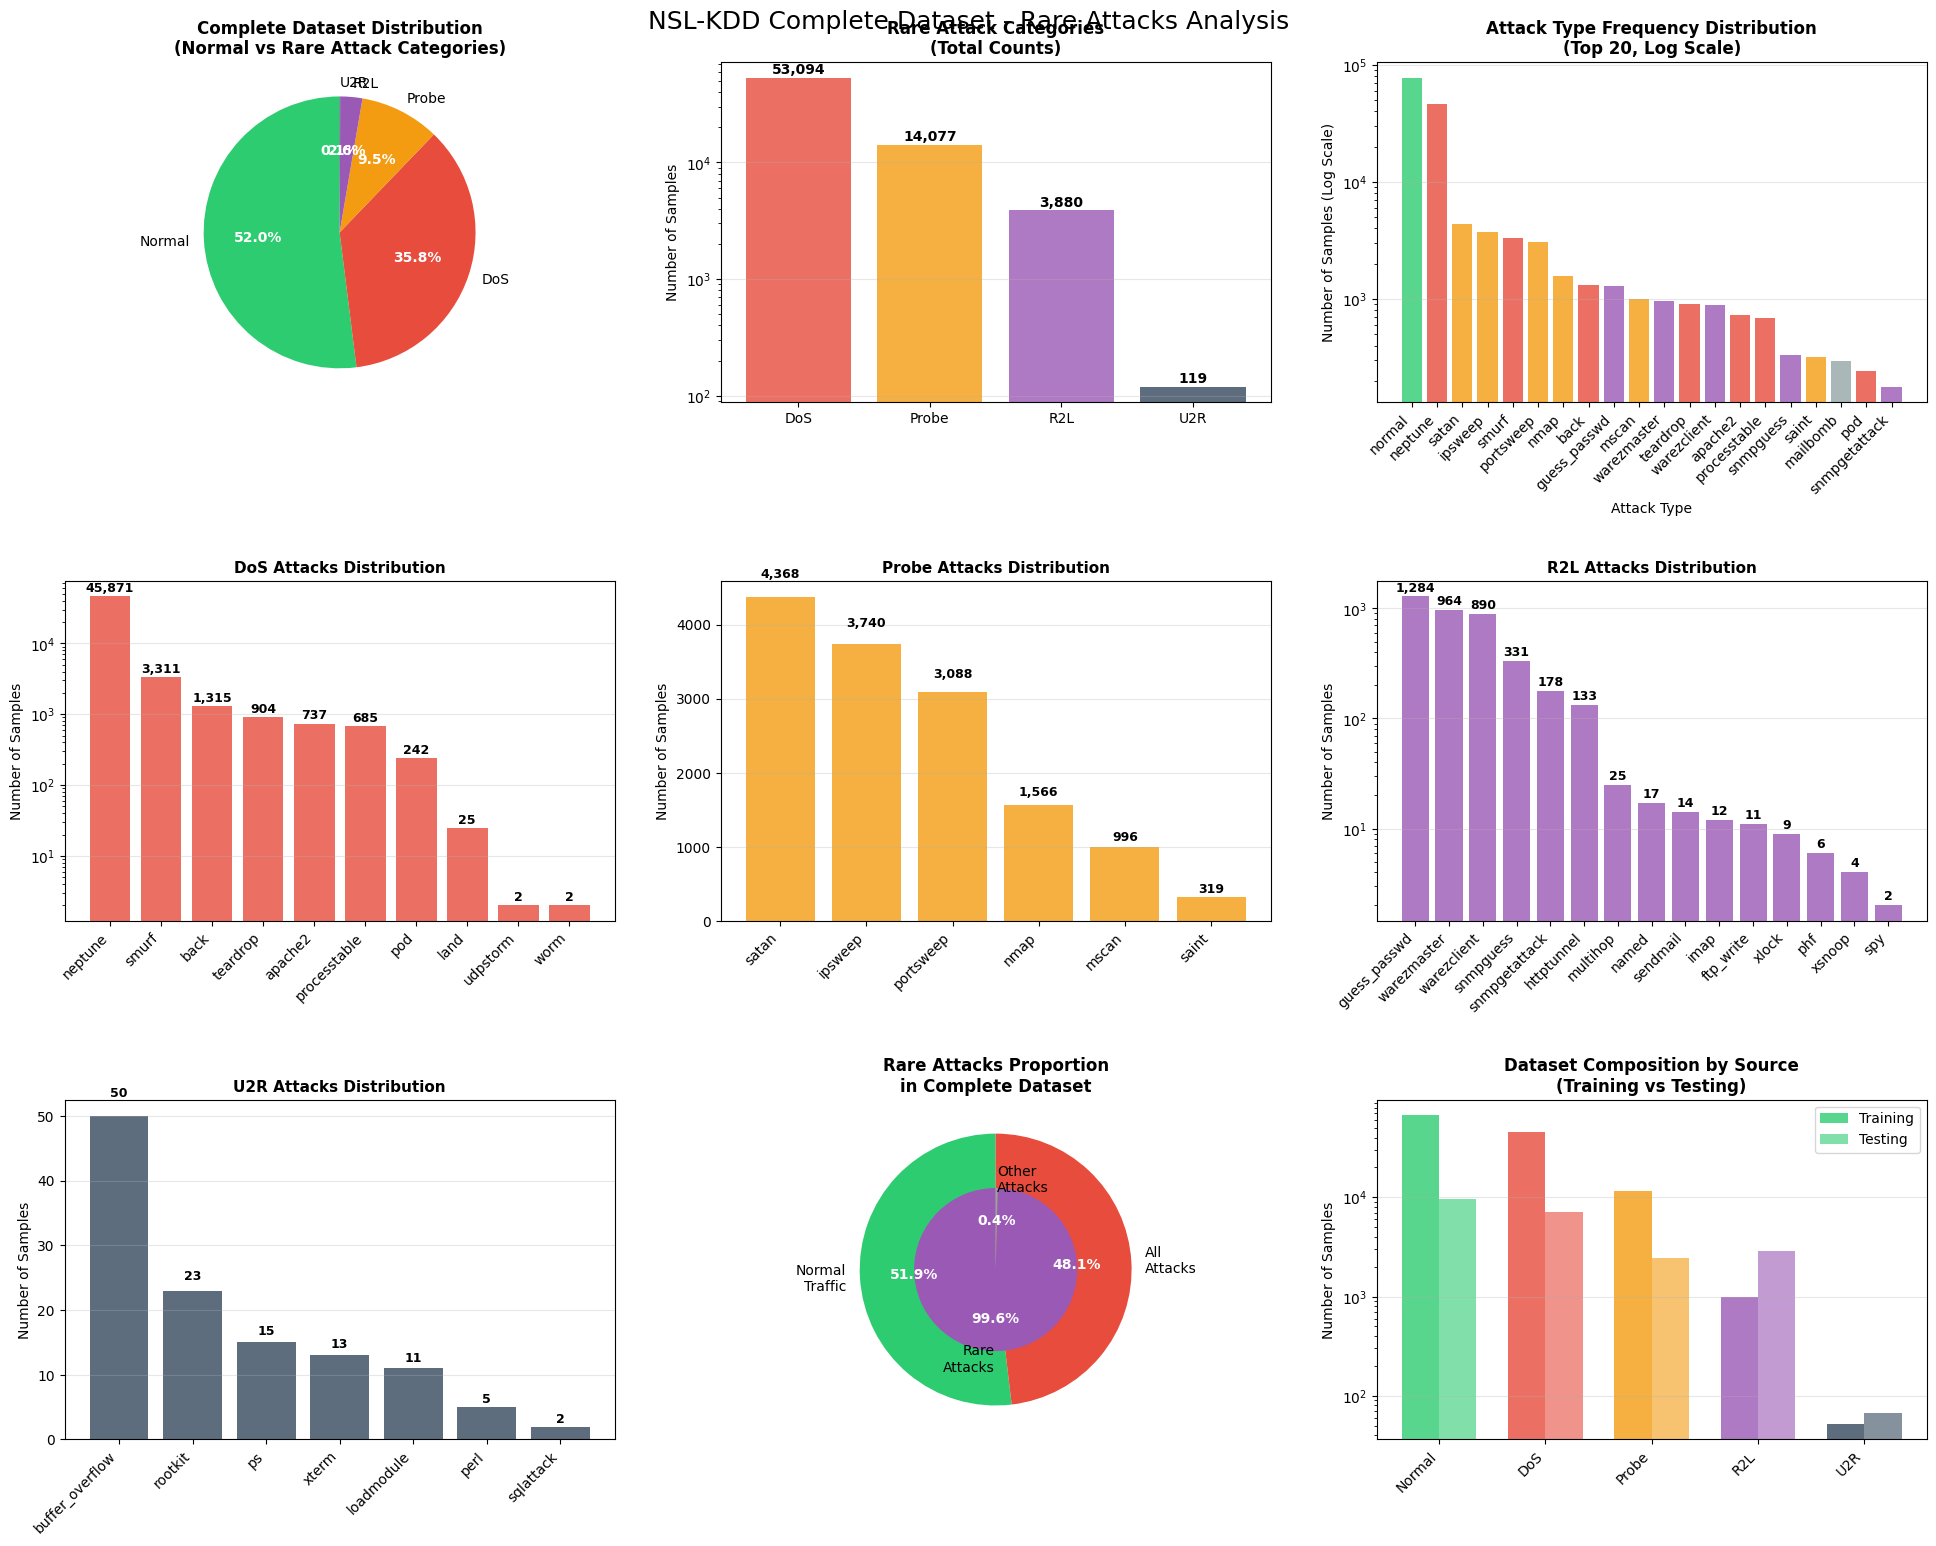


RARE ATTACKS SUMMARY REPORT

📊 DATASET OVERVIEW:
   • Total samples: 148,517
   • Normal traffic: 77,054 (51.88%)
   • Total rare attacks: 71,170 (47.920%)
   • Imbalance ratio (Normal:Rare): 1.1:1

🎯 RARE ATTACK CATEGORIES:
   • DoS   :   53,094 (35.749% of total,  74.6% of rare)
   • Probe :   14,077 ( 9.478% of total,  19.8% of rare)
   • R2L   :    3,880 ( 2.612% of total,   5.5% of rare)
   • U2R   :      119 ( 0.080% of total,   0.2% of rare)

🔍 RAREST ATTACKS (< 0.01% of dataset):
   • udpstorm             (DoS ):      2 ( 0.00135%)
   • worm                 (DoS ):      2 ( 0.00135%)
   • spy                  (R2L ):      2 ( 0.00135%)
   • sqlattack            (U2R ):      2 ( 0.00135%)
   • xsnoop               (R2L ):      4 ( 0.00269%)
   • perl                 (U2R ):      5 ( 0.00337%)
   • phf                  (R2L ):      6 ( 0.00404%)
   • xlock                (R2L ):      9 ( 0.00606%)
   • ftp_write            (R2L ):     11 ( 0.00741%)
   • loadmodule           (U2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from collections import defaultdict

# Set style for better-looking plots
plt.style.use('default')
sns.set_palette("husl")

# Define the dataset folder path
DATASET_FOLDER = "../raw/NSL_KDD_DATASET/"

# Define the column names for NSL-KDD TXT files
column_names = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins',
    'logged_in', 'num_compromised', 'root_shell', 'su_attempted',
    'num_root', 'num_file_creations', 'num_shells', 'num_access_files',
    'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count',
    'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate',
    'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate',
    'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate',
    'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate',
    'dst_host_srv_serror_rate', 'dst_host_rerror_rate',
    'dst_host_srv_rerror_rate', 'attack_type', 'difficulty_level'
]

def get_attack_categories():
    """Define attack categories with their specific attack types"""
    return {
        'DoS': ['back', 'land', 'neptune', 'pod', 'smurf', 'teardrop', 'apache2', 'udpstorm', 'processtable', 'worm'],
        'Probe': ['ipsweep', 'nmap', 'portsweep', 'satan', 'mscan', 'saint'],
        'R2L': ['ftp_write', 'guess_passwd', 'imap', 'multihop', 'phf', 'spy', 'warezclient', 'warezmaster', 
                'sendmail', 'named', 'snmpgetattack', 'snmpguess', 'xlock', 'xsnoop', 'httptunnel'],
        'U2R': ['buffer_overflow', 'loadmodule', 'perl', 'rootkit', 'ps', 'sqlattack', 'xterm']
    }

def get_category_colors():
    """Define colors for visualization"""
    return {
        'Normal': '#2ecc71',    # Green
        'DoS': '#e74c3c',       # Red
        'Probe': '#f39c12',     # Orange
        'R2L': '#9b59b6',       # Purple
        'U2R': '#34495e',       # Dark gray
        'Other': '#95a5a6'      # Light gray
    }

def load_complete_dataset():
    """
    Load both training and testing datasets and combine them
    
    Returns:
        tuple: (combined_data, train_data, test_data)
    """
    print("Loading Complete NSL-KDD Dataset...")
    print("-" * 50)
    
    # Load training data
    train_file = os.path.join(DATASET_FOLDER, "KDDTrain+.TXT")
    print(f"Loading training data from: {train_file}")
    try:
        train_data = pd.read_csv(train_file, names=column_names, skipinitialspace=True)
        train_data['attack_type'] = train_data['attack_type'].str.rstrip('.')
        train_data['dataset'] = 'Train'
        print(f"✓ Training data loaded: {train_data.shape}")
    except Exception as e:
        print(f"✗ Error loading training data: {e}")
        return None, None, None
    
    # Load test data
    test_file = os.path.join(DATASET_FOLDER, "KDDTest+.TXT")
    print(f"Loading test data from: {test_file}")
    try:
        test_data = pd.read_csv(test_file, names=column_names, skipinitialspace=True)
        test_data['attack_type'] = test_data['attack_type'].str.rstrip('.')
        test_data['dataset'] = 'Test'
        print(f"✓ Test data loaded: {test_data.shape}")
    except Exception as e:
        print(f"✗ Error loading test data: {e}")
        return None, train_data, None
    
    # Combine datasets
    combined_data = pd.concat([train_data, test_data], ignore_index=True)
    print(f"✓ Combined dataset created: {combined_data.shape}")
    
    return combined_data, train_data, test_data

def categorize_attack(attack_type):
    """Categorize attacks into main types"""
    categories = get_attack_categories()
    
    if attack_type == 'normal':
        return 'Normal'
    
    for category, attacks in categories.items():
        if attack_type in attacks:
            return category
    
    return 'Other'

def analyze_complete_dataset_rare_attacks(data):
    """
    Comprehensive analysis of rare attacks in the complete dataset
    
    Args:
        data (pd.DataFrame): Complete dataset
    
    Returns:
        dict: Analysis results
    """
    categories = get_attack_categories()
    
    print("\n" + "=" * 80)
    print("COMPLETE DATASET RARE ATTACK ANALYSIS")
    print("=" * 80)
    
    total_samples = len(data)
    normal_count = (data['attack_type'] == 'normal').sum()
    total_attacks = total_samples - normal_count
    
    print(f"\nDATASET OVERVIEW:")
    print(f"Total samples: {total_samples:,}")
    print(f"Normal traffic: {normal_count:,} ({(normal_count/total_samples)*100:.2f}%)")
    print(f"Total attacks: {total_attacks:,} ({(total_attacks/total_samples)*100:.2f}%)")
    
    # Analyze each rare attack category
    results = {}
    rare_attacks_total = 0
    
    print(f"\nRARE ATTACK CATEGORIES BREAKDOWN:")
    print("-" * 60)
    
    for category, attack_list in categories.items():
        category_total = 0
        category_details = {}
        
        print(f"\n{category} ATTACKS:")
        
        for attack in attack_list:
            count = (data['attack_type'] == attack).sum()
            percentage = (count / total_samples) * 100
            category_details[attack] = {
                'count': count,
                'percentage': percentage
            }
            category_total += count
            
            if count > 0:
                print(f"  {attack:<20}: {count:>8,} ({percentage:>6.3f}%)")
        
        category_percentage = (category_total / total_samples) * 100
        rare_attacks_total += category_total
        
        results[category] = {
            'total': category_total,
            'percentage': category_percentage,
            'details': category_details
        }
        
        print(f"  {'TOTAL ' + category + ':':<21} {category_total:>8,} ({category_percentage:>6.3f}%)")
    
    # Summary
    rare_percentage = (rare_attacks_total / total_samples) * 100
    print(f"\nSUMMARY:")
    print(f"Total rare attacks (DoS+Probe+R2L+U2R): {rare_attacks_total:,} ({rare_percentage:.3f}%)")
    print(f"Rare attacks vs Normal ratio: 1:{normal_count/rare_attacks_total:.1f}")
    
    results['summary'] = {
        'total_samples': total_samples,
        'normal_count': normal_count,
        'rare_attacks_total': rare_attacks_total,
        'rare_percentage': rare_percentage
    }
    
    return results

def plot_complete_dataset_overview(data, save_plots=False):
    """
    Create comprehensive visualization for the complete dataset
    
    Args:
        data (pd.DataFrame): Complete dataset
        save_plots (bool): Whether to save plots to files
    """
    
    fig = plt.figure(figsize=(20, 16))
    
    # 1. Overall distribution pie chart
    ax1 = plt.subplot(3, 3, 1)
    plot_overall_distribution_pie(data, ax1)
    
    # 2. Rare attack categories breakdown
    ax2 = plt.subplot(3, 3, 2)
    plot_rare_categories_bar(data, ax2)
    
    # 3. Attack frequency distribution (log scale)
    ax3 = plt.subplot(3, 3, 3)
    plot_attack_frequency_distribution(data, ax3)
    
    # 4. DoS attacks detailed
    ax4 = plt.subplot(3, 3, 4)
    plot_category_detailed_complete(data, 'DoS', ax4)
    
    # 5. Probe attacks detailed
    ax5 = plt.subplot(3, 3, 5)
    plot_category_detailed_complete(data, 'Probe', ax5)
    
    # 6. R2L attacks detailed
    ax6 = plt.subplot(3, 3, 6)
    plot_category_detailed_complete(data, 'R2L', ax6)
    
    # 7. U2R attacks detailed
    ax7 = plt.subplot(3, 3, 7)
    plot_category_detailed_complete(data, 'U2R', ax7)
    
    # 8. Rare attacks proportion visualization
    ax8 = plt.subplot(3, 3, 8)
    plot_rare_attacks_proportion(data, ax8)
    
    # 9. Dataset composition by source
    ax9 = plt.subplot(3, 3, 9)
    plot_dataset_source_composition(data, ax9)
    
    plt.tight_layout(pad=3.0)
    plt.suptitle('NSL-KDD Complete Dataset - Rare Attacks Analysis', fontsize=18, y=0.98)
    
    if save_plots:
        plt.savefig('nsl_kdd_complete_rare_attacks.png', dpi=300, bbox_inches='tight')
        print("Complete dataset analysis saved as 'nsl_kdd_complete_rare_attacks.png'")
    
    plt.show()

def plot_overall_distribution_pie(data, ax):
    """Plot overall distribution of normal vs rare attack categories"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    # Calculate counts
    normal_count = (data['attack_type'] == 'normal').sum()
    category_counts = {'Normal': normal_count}
    
    for category, attacks in categories.items():
        count = sum((data['attack_type'] == attack).sum() for attack in attacks)
        if count > 0:
            category_counts[category] = count
    
    # Create pie chart
    labels = list(category_counts.keys())
    sizes = list(category_counts.values())
    pie_colors = [colors[label] for label in labels]
    
    wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', 
                                     colors=pie_colors, startangle=90)
    
    # Enhance text
    for autotext in autotexts:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)
    
    ax.set_title('Complete Dataset Distribution\n(Normal vs Rare Attack Categories)', 
                fontweight='bold', fontsize=12)

def plot_rare_categories_bar(data, ax):
    """Plot bar chart of rare attack categories"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    category_names = []
    category_counts = []
    category_colors = []
    
    for category, attacks in categories.items():
        count = sum((data['attack_type'] == attack).sum() for attack in attacks)
        if count > 0:
            category_names.append(category)
            category_counts.append(count)
            category_colors.append(colors[category])
    
    bars = ax.bar(category_names, category_counts, color=category_colors, alpha=0.8)
    
    # Add value labels
    for bar, count in zip(bars, category_counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.02,
               f'{count:,}', ha='center', va='bottom', fontweight='bold')
    
    ax.set_title('Rare Attack Categories\n(Total Counts)', fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

def plot_attack_frequency_distribution(data, ax):
    """Plot frequency distribution of all attack types"""
    attack_counts = data['attack_type'].value_counts()
    
    # Apply categorization for coloring
    colors = get_category_colors()
    categories = [categorize_attack(attack) for attack in attack_counts.index]
    bar_colors = [colors[cat] for cat in categories]
    
    # Plot top 20 for readability
    top_20 = attack_counts.head(20)
    top_colors = bar_colors[:20]
    
    bars = ax.bar(range(len(top_20)), top_20.values, color=top_colors, alpha=0.8)
    
    ax.set_title('Attack Type Frequency Distribution\n(Top 20, Log Scale)', 
                fontweight='bold', fontsize=12)
    ax.set_xlabel('Attack Type')
    ax.set_ylabel('Number of Samples (Log Scale)')
    ax.set_yscale('log')
    ax.set_xticks(range(len(top_20)))
    ax.set_xticklabels(top_20.index, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)

def plot_category_detailed_complete(data, category, ax):
    """Plot detailed breakdown for a specific rare attack category"""
    categories = get_attack_categories()
    colors = get_category_colors()
    
    if category not in categories:
        return
    
    attacks = categories[category]
    
    # Get counts for each attack in this category
    attack_data = []
    for attack in attacks:
        count = (data['attack_type'] == attack).sum()
        if count > 0:
            attack_data.append((attack, count))
    
    if not attack_data:
        ax.text(0.5, 0.5, f'No {category} attacks found', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_title(f'{category} Attacks Distribution', fontweight='bold')
        return
    
    # Sort by count
    attack_data.sort(key=lambda x: x[1], reverse=True)
    attack_names, attack_counts = zip(*attack_data)
    
    bars = ax.bar(attack_names, attack_counts, color=colors[category], alpha=0.8)
    
    # Add value labels
    for bar, count in zip(bars, attack_counts):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + height*0.05,
               f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    
    ax.set_title(f'{category} Attacks Distribution', fontweight='bold', fontsize=11)
    ax.set_ylabel('Number of Samples')
    ax.set_xticklabels(attack_names, rotation=45, ha='right')
    ax.grid(axis='y', alpha=0.3)
    
    # Use log scale if wide range
    if max(attack_counts) / min(attack_counts) > 100:
        ax.set_yscale('log')

def plot_rare_attacks_proportion(data, ax):
    """Visualize the proportion of rare attacks in the overall dataset"""
    categories = get_attack_categories()
    
    normal_count = (data['attack_type'] == 'normal').sum()
    rare_total = sum(sum((data['attack_type'] == attack).sum() for attack in attacks) 
                    for attacks in categories.values())
    other_attacks = len(data) - normal_count - rare_total
    
    # Create a nested pie chart
    # Outer pie: Normal vs All Attacks
    outer_sizes = [normal_count, len(data) - normal_count]
    outer_labels = ['Normal\nTraffic', 'All\nAttacks']
    outer_colors = ['#2ecc71', '#e74c3c']
    
    # Inner pie: Breakdown of attacks
    inner_sizes = [rare_total, other_attacks] if other_attacks > 0 else [rare_total]
    inner_labels = ['Rare\nAttacks', 'Other\nAttacks'] if other_attacks > 0 else ['Rare\nAttacks']
    inner_colors = ['#9b59b6', '#95a5a6'] if other_attacks > 0 else ['#9b59b6']
    
    # Outer pie
    wedges1, texts1, autotexts1 = ax.pie(outer_sizes, labels=outer_labels, autopct='%1.1f%%',
                                        colors=outer_colors, radius=1, startangle=90)
    
    # Inner pie
    wedges2, texts2, autotexts2 = ax.pie(inner_sizes, labels=inner_labels, autopct='%1.1f%%',
                                        colors=inner_colors, radius=0.6, startangle=90)
    
    # Enhance text
    for autotext in autotexts1 + autotexts2:
        autotext.set_color('white')
        autotext.set_fontweight('bold')
    
    ax.set_title('Rare Attacks Proportion\nin Complete Dataset', fontweight='bold', fontsize=12)

def plot_dataset_source_composition(data, ax):
    """Show composition by training vs testing data source"""
    if 'dataset' not in data.columns:
        ax.text(0.5, 0.5, 'Dataset source info not available', ha='center', va='center', 
                transform=ax.transAxes, fontsize=12)
        ax.set_title('Dataset Source Composition', fontweight='bold')
        return
    
    categories = get_attack_categories()
    
    # Calculate counts by source and category
    train_data = data[data['dataset'] == 'Train']
    test_data = data[data['dataset'] == 'Test']
    
    composition_data = {
        'Normal': [
            (train_data['attack_type'] == 'normal').sum(),
            (test_data['attack_type'] == 'normal').sum()
        ]
    }
    
    for category, attacks in categories.items():
        train_count = sum((train_data['attack_type'] == attack).sum() for attack in attacks)
        test_count = sum((test_data['attack_type'] == attack).sum() for attack in attacks)
        composition_data[category] = [train_count, test_count]
    
    # Create stacked bar chart
    categories_list = list(composition_data.keys())
    train_counts = [composition_data[cat][0] for cat in categories_list]
    test_counts = [composition_data[cat][1] for cat in categories_list]
    
    x = np.arange(len(categories_list))
    width = 0.35
    
    colors = get_category_colors()
    category_colors = [colors[cat] for cat in categories_list]
    
    bars1 = ax.bar(x - width/2, train_counts, width, label='Training', 
                   color=category_colors, alpha=0.8)
    bars2 = ax.bar(x + width/2, test_counts, width, label='Testing', 
                   color=category_colors, alpha=0.6)
    
    ax.set_title('Dataset Composition by Source\n(Training vs Testing)', 
                fontweight='bold', fontsize=12)
    ax.set_ylabel('Number of Samples')
    ax.set_xticks(x)
    ax.set_xticklabels(categories_list, rotation=45, ha='right')
    ax.legend()
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3)

def create_rare_attacks_summary_report(data):
    """Generate a comprehensive text summary of rare attacks"""
    categories = get_attack_categories()
    
    print("\n" + "=" * 80)
    print("RARE ATTACKS SUMMARY REPORT")
    print("=" * 80)
    
    total_samples = len(data)
    normal_count = (data['attack_type'] == 'normal').sum()
    
    print(f"\n📊 DATASET OVERVIEW:")
    print(f"   • Total samples: {total_samples:,}")
    print(f"   • Normal traffic: {normal_count:,} ({(normal_count/total_samples)*100:.2f}%)")
    
    # Calculate rare attacks summary
    rare_summary = {}
    total_rare = 0
    
    for category, attacks in categories.items():
        category_count = sum((data['attack_type'] == attack).sum() for attack in attacks)
        rare_summary[category] = category_count
        total_rare += category_count
    
    print(f"   • Total rare attacks: {total_rare:,} ({(total_rare/total_samples)*100:.3f}%)")
    print(f"   • Imbalance ratio (Normal:Rare): {normal_count/total_rare:.1f}:1")
    
    print(f"\n🎯 RARE ATTACK CATEGORIES:")
    for category, count in rare_summary.items():
        percentage = (count / total_samples) * 100
        rare_percentage = (count / total_rare) * 100 if total_rare > 0 else 0
        print(f"   • {category:<6}: {count:>8,} ({percentage:>6.3f}% of total, {rare_percentage:>5.1f}% of rare)")
    
    print(f"\n🔍 RAREST ATTACKS (< 0.01% of dataset):")
    ultra_rare = []
    for category, attacks in categories.items():
        for attack in attacks:
            count = (data['attack_type'] == attack).sum()
            percentage = (count / total_samples) * 100
            if 0 < count < total_samples * 0.0001:  # Less than 0.01%
                ultra_rare.append((attack, count, percentage, category))
    
    ultra_rare.sort(key=lambda x: x[1])
    for attack, count, percentage, category in ultra_rare:
        print(f"   • {attack:<20} ({category:<4}): {count:>6,} ({percentage:>8.5f}%)")
    
    if not ultra_rare:
        print("   • No ultra-rare attacks found (< 0.01% threshold)")

# Main execution function
def main():
    """Main function to run the complete analysis"""
    print("NSL-KDD Complete Dataset Rare Attacks Analysis")
    print("=" * 60)
    
    # Load all data
    combined_data, train_data, test_data = load_complete_dataset()
    
    if combined_data is None:
        print("Failed to load datasets. Please check file paths.")
        return None
    
    # Perform analysis
    results = analyze_complete_dataset_rare_attacks(combined_data)
    
    # Create visualizations
    plot_complete_dataset_overview(combined_data, save_plots=True)
    
    # Generate summary report
    create_rare_attacks_summary_report(combined_data)
    
    return combined_data, results

# Example usage
if __name__ == "__main__":
    # Run complete analysis
    data, analysis_results = main()
    
    print(f"\n{'='*60}")
    print("ANALYSIS COMPLETE!")
    print("="*60)
    print("The complete dataset has been loaded and analyzed.")
    print("Visualizations have been created and saved.")
    print("\nYou can now access:")
    print("• data - Complete combined dataset")
    print("• analysis_results - Detailed analysis results")